In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import joblib
import time
import shap
!pip install lime
import lime
import lime.lime_tabular
import warnings
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,

)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.feature_selection import mutual_info_classif
from matplotlib.colors import LinearSegmentedColormap
from scipy.special import expit

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

In [ ]:
df = pd.read_csv('CredGuardV2 (1).csv')
df.head()

,timestamp,src_ip,username,password,asn,location,status,label,source,ip_type,...,fail_attempt,fail_ratio,mean_iat,std_iat,password_length,password_complexity,day_of_week,hour,hour_sin,hour_cos
0,2024-08-15 02:12:37,1.180.230.98,nobody,666666,4134,CN,0,1,df1,1,...,1,1.0,0.0,0.0,6.0,1.0,3,2,5.000000e-01,0.866025
1,2024-08-14 16:28:57,1.212.24.36,support,p@ssw0rd,3786,KR,0,1,df1,1,...,1,1.0,0.0,0.0,8.0,3.0,2,16,-8.660254e-01,-0.500000
2,2024-08-15 12:26:59,1.213.180.227,guest,44444444,3786,KR,0,1,df1,1,...,1,1.0,0.0,0.0,8.0,1.0,3,12,1.224647e-16,-1.000000
3,2024-08-15 04:11:52,1.214.209.210,login,0,3786,KR,0,1,df1,1,...,1,1.0,0.0,0.0,1.0,1.0,3,4,8.660254e-01,0.500000
4,2024-08-14 22:40:26,1.235.192.130,a123456789,a123456789,9318,KR,0,1,df1,1,...,1,1.0,0.0,0.0,10.0,2.0,2,22,-5.000000e-01,0.866025


Value counts in label column:
label
0    510183
1    509684
Name: count, dtype: int64


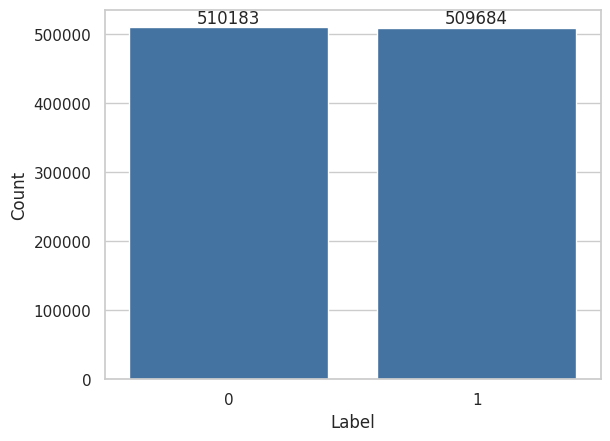

In [ ]:
sns.set_theme(style="whitegrid")
ax = sns.countplot(x='label', data=df, color='#3572B0')
ax.bar_label(ax.containers[0])
plt.xlabel('Label', fontsize=12)
plt.ylabel('Count', fontsize=12)
print("Value counts in label column:")
print(df['label'].value_counts())
plt.show()


Feature Engineering

In [ ]:
X = df.copy()
feature_groups = {}

# TIMESTAMP FEATURES
X['timestamp'] = pd.to_datetime(X['timestamp'], format='mixed', errors='coerce')
X['is_time_missing'] = X['timestamp'].isna().astype('int8')
X['hr']  = X['timestamp'].dt.hour.fillna(0).astype('int8')
X['dow'] = X['timestamp'].dt.dayofweek.fillna(0).astype('int8')
X['is_wknd?']  = (X['dow'].isin([4, 5])).astype('int8')
X['is_night?'] = ((X['hr'] < 6) | (X['hr'] >= 23)).astype('int8')
X = X.drop(columns=['timestamp'])

feature_groups['time'] = ['hr', 'dow', 'is_wknd?', 'is_night?']

# =======================
# USERNAME FEATURES
X['username'] = X['username'].astype(str)

# =======================
# PASSWORD FEATURES
X['p_len'] = pd.to_numeric(X['password_length'], errors='coerce').fillna(0).astype('int8')
X['p_comp'] = pd.to_numeric(X['password_complexity'], errors='coerce').fillna(0).astype('int8')

X['has_num'] = X['password'].astype(str).apply(lambda x: 1 if any(c.isdigit() for c in str(x)) else 0).astype('int8')
X['has_spec'] = X['password'].astype(str).apply(
    lambda x: 1 if any((not c.isalnum()) and (not c.isspace()) for c in x) else 0
).astype('int8')

X['p_score'] = ((X['p_comp'] * X['p_len']) / 10).astype('float32')

feature_groups['password'] = ['p_len', 'p_comp', 'has_num', 'has_spec', 'p_score']

# =======================
# IAT FEATURES
X['mean_iat'] = pd.to_numeric(X['mean_iat'], errors='coerce').fillna(0).astype('float32')
X['std_iat'] = pd.to_numeric(X['std_iat'], errors='coerce').fillna(0).astype('float32')
X['iat_var'] = (X['std_iat'] / (X['mean_iat'].clip(lower=1))).astype('float32')

feature_groups['iat'] = ['mean_iat', 'std_iat', 'iat_var']


# =======================
# LOGIN FEATURES
X['tries'] = pd.to_numeric(X['login_attempt'], errors='coerce').fillna(0).astype('int16')
X['fails'] = pd.to_numeric(X['fail_attempt'], errors='coerce').fillna(0).astype('int16')
X['fail_rate'] = pd.to_numeric(X['fail_ratio'], errors='coerce').fillna(0).astype('float32')

feature_groups['login'] = ['tries', 'fails', 'fail_rate']

X['target'] = X['label'].astype('int8')
print("Target distribution (0: Normal, 1: Attack):")
print(X['target'].value_counts())

Target distribution (0: Normal, 1: Attack):
target
0    510183
1    509684
Name: count, dtype: int64


Train/Test Split

In [ ]:
bad_features = ['label', 'target', 'status']
X_final = X.drop(columns=bad_features, errors='ignore')
y_final = X['target']

# 70% for Training
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, temp_idx = next(
    gss1.split(X_final, y_final, groups=X_final['src_ip']))

X_train = X_final.iloc[train_idx].copy()
y_train = y_final.iloc[train_idx].copy()
X_temp = X_final.iloc[temp_idx].copy()
y_temp = y_final.iloc[temp_idx].copy()

# 30% (15% for Test)(15% for Validation)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(
    gss2.split(X_temp, y_temp, groups=X_temp['src_ip']))

X_val = X_temp.iloc[val_idx].copy()
y_val = y_temp.iloc[val_idx].copy()
X_test = X_temp.iloc[test_idx].copy()
y_test = y_temp.iloc[test_idx].copy()

print(f"Train: {len(X_train)} ({len(X_train)/len(X_final)*100:.2f}%)")
print(f"Validation: {len(X_val)} ({len(X_val)/len(X_final)*100:.2f}%)")
print(f"Test: {len(X_test)} ({len(X_test)/len(X_final)*100:.2f}%)")

print("\n" + "="*50 + "\n")

def print_distribution(y, name):
    dist = y.value_counts(normalize=True) * 100
    print(f"{name} distribution:")
    print(dist)
    print("-" * 40)

print_distribution(y_train, "Train")
print_distribution(y_val, "Validation")
print_distribution(y_test, "Test")

train_ips = set(X_train['src_ip'])
val_ips   = set(X_val['src_ip'])
test_ips  = set(X_test['src_ip'])

print(f"\nOverlap Train-Val: {len(train_ips & val_ips)}")
print(f"Overlap Train-Test: {len(train_ips & test_ips)}")
print(f"Overlap Val-Test: {len(val_ips & test_ips)}")

X_train = X_train.drop(columns=['src_ip'])
X_val   = X_val.drop(columns=['src_ip'])
X_test  = X_test.drop(columns=['src_ip'])

print("\n src_ip removed")

Train: 704222 (69.05%)
Validation: 173022 (16.97%)
Test: 142623 (13.98%)


Train distribution:
target
0    52.530026
1    47.469974
Name: proportion, dtype: float64
----------------------------------------
Validation distribution:
target
1    59.585486
0    40.414514
Name: proportion, dtype: float64
----------------------------------------
Test distribution:
target
1    50.688879
0    49.311121
Name: proportion, dtype: float64
----------------------------------------

Overlap Train-Val: 0
Overlap Train-Test: 0
Overlap Val-Test: 0

 src_ip removed


In [ ]:
u_map = X_train['username'].value_counts(normalize=True)
for ds in [X_train, X_val, X_test]:
    ds['u_freq'] = ds['username'].map(u_map).fillna(0).astype('float32')
feature_groups['user'] = ['u_freq']


loc_map = X_train['location'].value_counts(normalize=True)
for ds in [X_train, X_val, X_test]:
    ds['loc_freq'] = ds['location'].map(loc_map).fillna(0).astype('float32')

asn_map = X_train['asn'].value_counts(normalize=True)
for ds in [X_train, X_val, X_test]:
    ds['asn_freq'] = ds['asn'].map(asn_map).fillna(0).astype('float32')
feature_groups['network'] = ['asn_freq', 'loc_freq']

failure_threshold = X['fail_rate'].quantile(0.95)
fast_limit = X['mean_iat'].quantile(0.05)
reg_limit  = X['std_iat'].quantile(0.10)

for ds in [X_train, X_val, X_test]:
    ds['is_v_fast?'] = (ds['mean_iat'] < fast_limit).astype('int8')
    ds['is_v_reg?']  = (ds['std_iat'] < reg_limit).astype('int8')
    ds['fail_rate']  = pd.to_numeric(ds['fail_ratio'], errors='coerce').fillna(0).astype('float32')
    ds['is_failure?'] = (ds['fail_rate'] >= failure_threshold).astype('int8')

    ds['risk_score'] = (
        ds['is_failure?'] * 3 +
        ds['is_v_fast?'] * 2 +
        (ds['p_score'] < 3).astype(int) * 2 +
        ds['is_night?'] * 1 +
        ds['is_wknd?'] * 1
    ).astype('int8')

feature_groups['iat'] = ['is_v_fast?', 'is_v_reg?']
feature_groups['login'] = ['fail_rate', 'is_failure?']
feature_groups['risk'] = ['risk_score']

In [ ]:
# PREPARE TRAINING FEATURES
training_features = [
    'hr', 'dow', 'is_wknd?', 'is_night?',
    'p_len', 'p_comp', 'has_num', 'has_spec', 'p_score',
    'u_freq', 'loc_freq', 'asn_freq',
    'mean_iat', 'std_iat', 'iat_var','is_v_fast?', 'is_v_reg?',
    'tries', 'fails', 'fail_rate', 'is_failure?'
]

X_train_final = X_train[training_features].copy()
X_val_final   = X_val[training_features].copy()
X_test_final  = X_test[training_features].copy()

y_train_final = y_train.copy()
y_val_final   = y_val.copy()
y_test_final  = y_test.copy()

print("Select Features:")
print(f"Total features: {len(training_features)}")
print(f"Groups: {list(feature_groups.keys())}")
print(f"Feature matrix: {X_final.shape}")
print(f"Target vector: {y_final.shape}")
print(f"Target distribution:\n{y_final.value_counts().sort_index()}")

Select Features:
Total features: 21
Groups: ['time', 'password', 'iat', 'login', 'user', 'network', 'risk']
Feature matrix: (1019867, 33)
Target vector: (1019867,)
Target distribution:
target
0    510183
1    509684
Name: count, dtype: int64


Scale Feature

In [ ]:
X_train_num = X_train.select_dtypes(include=['number']).drop(columns=['src_ip'], errors='ignore')
X_val_num   = X_val.select_dtypes(include=['number']).drop(columns=['src_ip'], errors='ignore')
X_test_num  = X_test.select_dtypes(include=['number']).drop(columns=['src_ip'], errors='ignore')

scaler = StandardScaler()

cols = X_train_num.columns

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_num), columns=cols)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val_num), columns=cols)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_num), columns=cols)

Train SVM Model

In [ ]:

svm_model = Pipeline([
    ('svm', SGDClassifier(
        loss='modified_huber',
        penalty='elasticnet',
        alpha=1e-4,
        l1_ratio=0.15,
        max_iter=2000,
        tol=1e-4,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=5,
        class_weight='balanced',
        random_state=42
    ))
])

svm_model.fit(X_train_scaled, y_train)

Pipeline(steps=[('svm',
                 SGDClassifier(class_weight='balanced', early_stopping=True,
                               loss='modified_huber', max_iter=2000,
                               penalty='elasticnet', random_state=42,
                               tol=0.0001))])

Model Evaluation

In [ ]:
#EVALUATION
y_train_pred = svm_model.predict(X_train_scaled)
y_val_pred   = svm_model.predict(X_val_scaled)
y_test_pred  = svm_model.predict(X_test_scaled)

scores = svm_model.decision_function(X_test_scaled)
y_test_prob_svm = expit(scores)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test, y_test_pred)
val_acc   = accuracy_score(y_val, y_val_pred)
test_f1   = f1_score(y_test, y_test_pred, average='weighted')

print("Accuracy Scores:")
print(f"  • Training: {train_acc:.4f}")
print(f"  • Test: {test_acc:.4f}")
print(f"  • Validation: {val_acc:.4f}")
print(f"  • F1-Score (Weighted): {test_f1:.4f}")

print("Unique in y_test:", np.unique(y_test))
print("Unique in y_test_pred:", np.unique(y_test_pred))


Accuracy Scores:
  • Training: 0.7300
  • Test: 0.7121
  • Validation: 0.7715
  • F1-Score (Weighted): 0.7109
Unique in y_test: [0 1]
Unique in y_test_pred: [0 1]


 Accuracy comparison bar chart

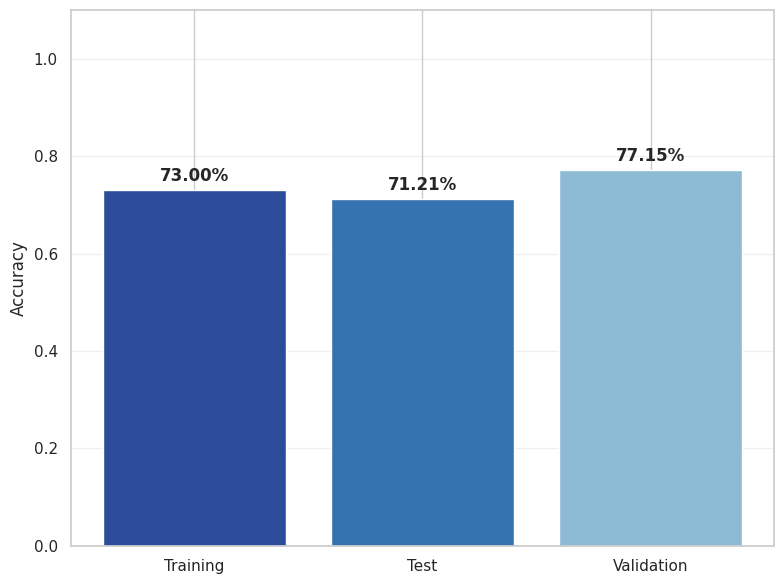

In [ ]:
plt.figure(figsize=(8, 6))
accuracies = [train_acc, test_acc, val_acc]
bars = plt.bar(['Training', 'Test', 'Validation'], accuracies,
               color=['#2B4C9B', '#3572B0', '#8DBBD5'])

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{acc:.2%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylim(0, 1.1)
#plt.title('Model Accuracy: Training vs Test vs Validation', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Class Distribution bar chart

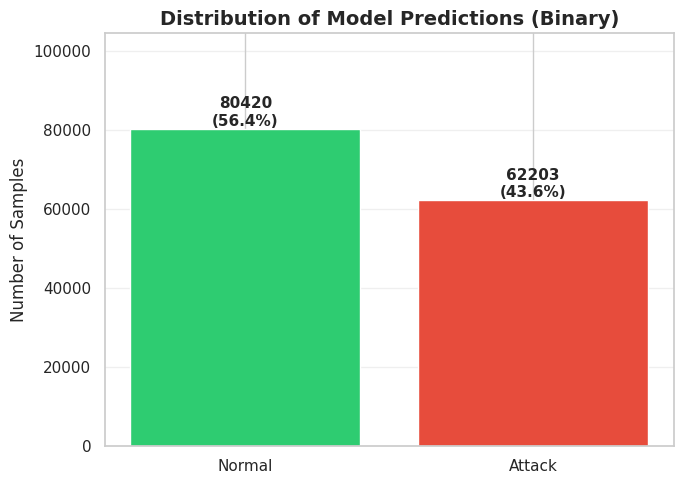

In [ ]:
plt.figure(figsize=(7, 5))
colors = ['#2ECC71', '#E74C3C']

class_names = ['Normal', 'Attack']

class_counts = pd.Series(y_test_pred).value_counts().sort_index()
total = len(y_test_pred)

bars = plt.bar(class_names, [class_counts.get(i, 0) for i in range(2)], color=colors)

plt.ylim(0, class_counts.max() * 1.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({height/total*100:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Distribution of Model Predictions (Binary)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Samples', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Mutual Information

Top 15 Mutual Information Scores:
                Feature  MI_Score
5              mean_iat  0.177270
6               std_iat  0.161383
23              iat_var  0.155123
4            fail_ratio  0.133250
26            fail_rate  0.132708
19               p_comp  0.106486
8   password_complexity  0.104324
7       password_length  0.099769
22              p_score  0.097877
18                p_len  0.096540
3          fail_attempt  0.095982
25                fails  0.093902
1                   iat  0.074320
2         login_attempt  0.057623
24                tries  0.055469


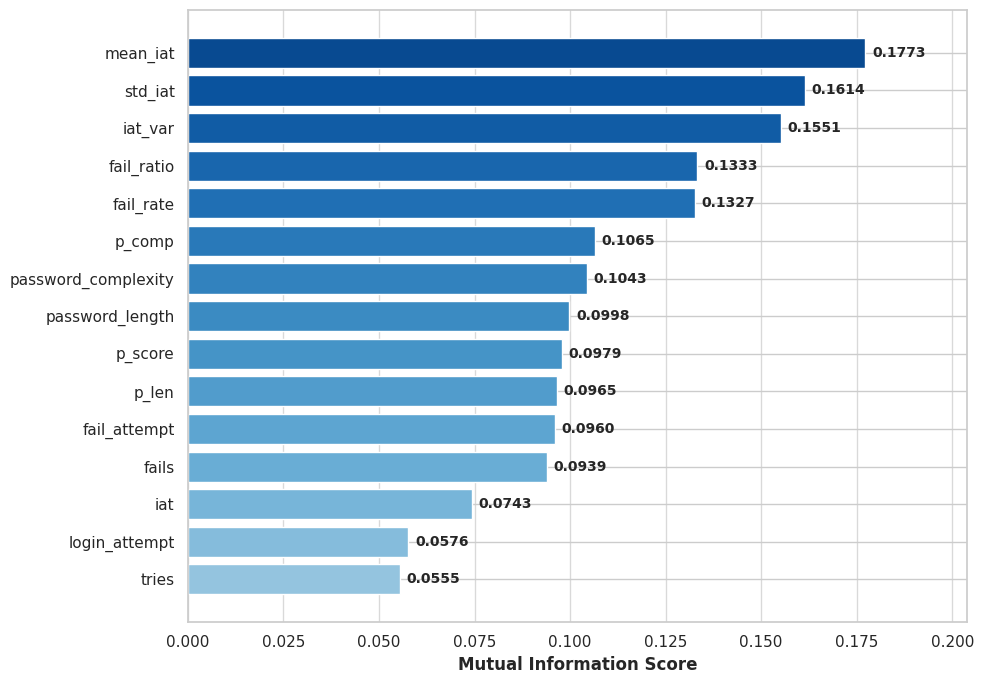

In [ ]:
feature_columns = X_final.select_dtypes(include=['number']).columns

X_train_df = pd.DataFrame(X_train, columns=feature_columns)

X_train_df = X_train_df.fillna(0)

sample_idx = np.random.choice(len(X_train_df), size=20000, replace=False)
X_sample = X_train_df.iloc[sample_idx]
y_sample = y_train.iloc[sample_idx]

mi_scores = mutual_info_classif(X_sample, y_sample, random_state=42)

mi_df = pd.DataFrame({
    'Feature': feature_columns,
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False)

print("Top 15 Mutual Information Scores:")
print(mi_df.head(15))

plt.figure(figsize=(10, 7))
top_15_mi = mi_df.head(15)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_15_mi)))

bars = plt.barh(range(len(top_15_mi)), top_15_mi['MI_Score'].values, color=colors[::-1])

plt.grid(visible=True, axis='x', color='black', linestyle='-', alpha=0.15)
plt.yticks(range(len(top_15_mi)), top_15_mi['Feature'].values)
plt.xlabel('Mutual Information Score', fontsize=12, fontweight='bold')

plt.gca().invert_yaxis()
plt.xlim(0, top_15_mi['MI_Score'].max() * 1.15)

for i, (bar, val) in enumerate(zip(bars, top_15_mi['MI_Score'].values)):
    plt.text(
        bar.get_width() + (top_15_mi['MI_Score'].max() * 0.01),
        bar.get_y() + bar.get_height()/2,
        f'{val:.4f}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

Feature Importance

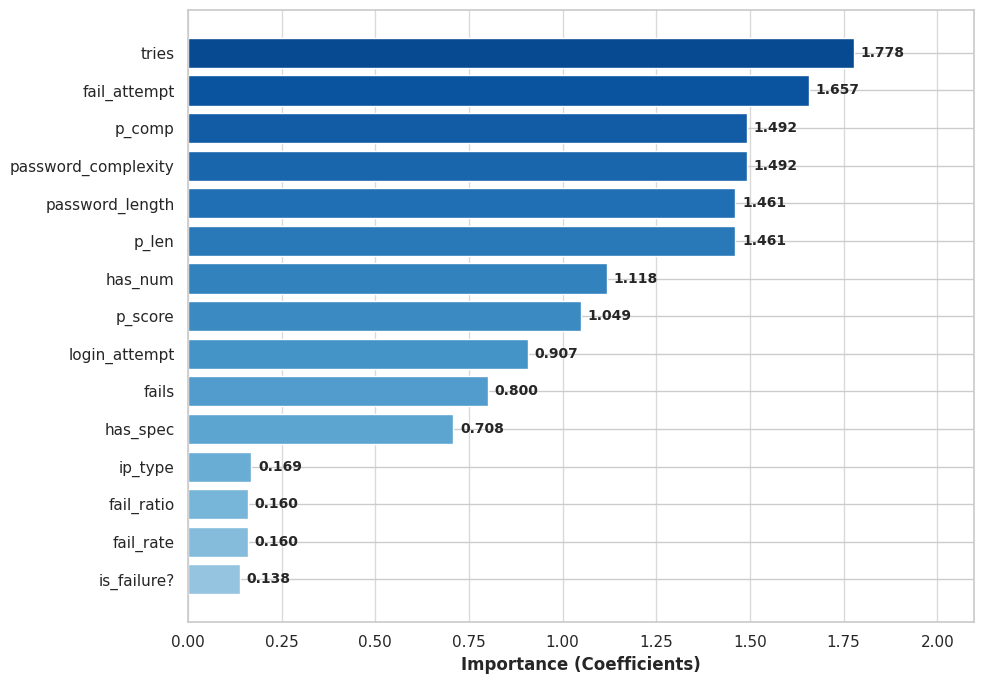

In [ ]:
model_step = svm_model.named_steps['svm']
importances = np.abs(model_step.coef_[0]) # نأخذ القيمة المطلقة للمعاملات

feature_columns = X_train_scaled.columns

top_features = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 7))
top_15 = top_features.head(15)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_15)))
bars = plt.barh(range(len(top_15)), top_15['Importance'].values, color=colors[::-1])

plt.grid(visible=True, axis='x', color='black', linestyle='-', alpha=0.15)
plt.yticks(range(len(top_15)), top_15['Feature'].values)
plt.xlabel('Importance (Coefficients)', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.xlim(0, top_15['Importance'].max() * 1.18)

for i, (bar, val) in enumerate(zip(bars, top_15['Importance'].values)):
    plt.text(
        bar.get_width() + (top_15['Importance'].max() * 0.01),
        bar.get_y() + bar.get_height()/2,
        f'{val:.3f}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

Correlation Matrix

In [ ]:
report_dict = classification_report(
    y_test,
    svm_model.predict(X_test_scaled),
    labels=[0, 1],
    target_names=['Normal', 'Attack'],
    output_dict=True,
    zero_division=0
)

df_report = pd.DataFrame(report_dict).transpose()

for col in ['precision', 'recall', 'f1-score']:
    df_report[col] = df_report[col].apply(lambda x: f"{x*100:.2f}%")

display(df_report)

,precision,recall,f1-score,support
Normal,68.19%,77.98%,72.76%,70329.000000
Attack,75.10%,64.62%,69.47%,72294.000000
accuracy,71.21%,71.21%,71.21%,0.712073
macro avg,71.65%,71.30%,71.11%,142623.000000
weighted avg,71.70%,71.21%,71.09%,142623.000000


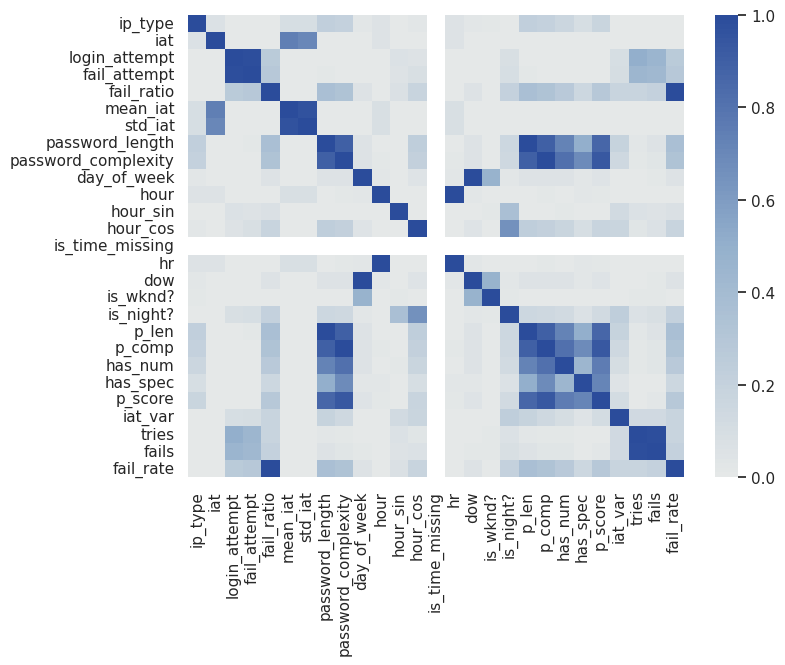

In [ ]:
plt.figure(figsize=(8,6))
colors = ["#E5E8E8", "#94B0CC", "#2B4C9B"]
n_bins = 100
sns.set_style("white")
cmap_name = "gray_to_blue"
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)
corr_matrix = X_final.corr(numeric_only=True)
sns.heatmap(corr_matrix, cmap=custom_cmap, annot=False, fmt=".2f", vmin=0, vmax=1)
plt.show()

Confusion Matrix


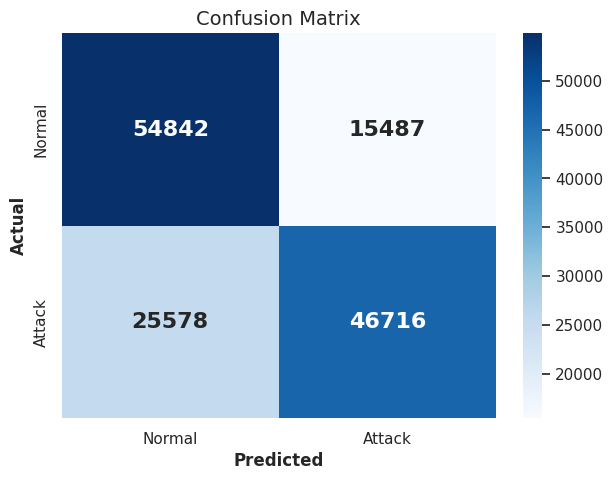

In [ ]:
class_names = ['Normal', 'Attack']

y_test_pred = svm_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues",
            annot_kws={"size": 16, "weight": "bold"})

plt.xlabel("Predicted", fontsize=12, fontweight='bold')
plt.ylabel("Actual", fontsize=12, fontweight='bold')
plt.title("Confusion Matrix", fontsize=14)
plt.show()

Classification report heatmap

In [ ]:
report = classification_report(
    y_test,
    y_test_pred,
    labels=[0, 1],
    target_names=['Normal', 'Attack'],
    output_dict=True,
    zero_division=0
)

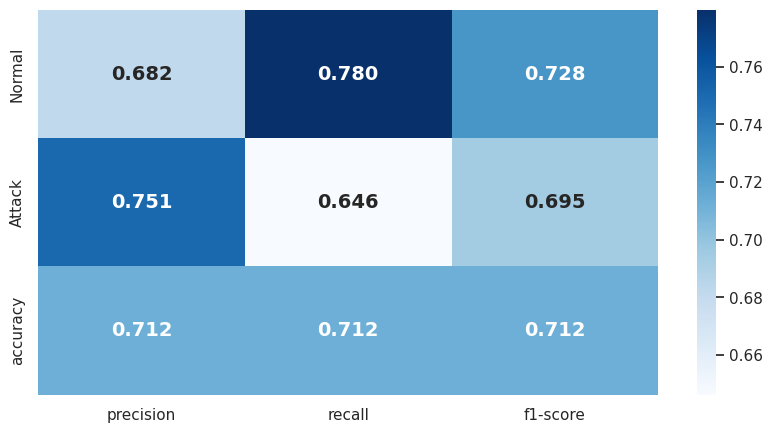

In [ ]:
report_df = pd.DataFrame(report).iloc[:-1, :3].T

plt.figure(figsize=(10, 5))
sns.heatmap(report_df, annot=True, fmt=".3f",
            cmap="Blues", annot_kws={"size": 14, "weight": "bold"})
#plt.title("Classification Report Heatmap")
#plt.tight_layout()
plt.show()

Operational Performance & Security Metrics

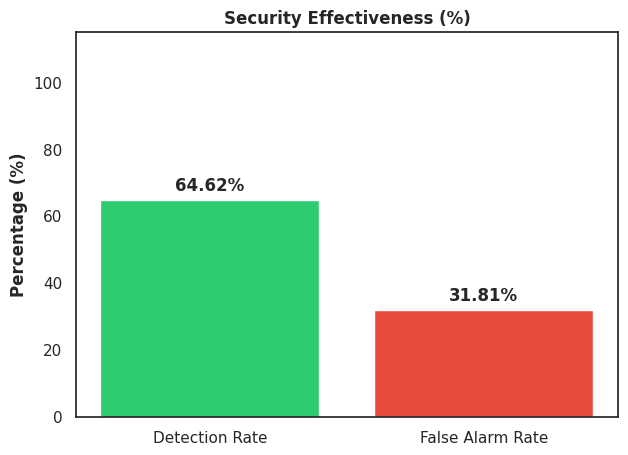

In [ ]:
attack_recall = report['Attack']['recall']
normal_precision = report['Normal']['precision']

# Define detection_rate and far_rate
detection_rate = attack_recall * 100
far_rate = (1 - normal_precision) * 100

fig, ax1 = plt.subplots(figsize=(7, 5))

metrics = ['Detection Rate', 'False Alarm Rate']
values = [detection_rate, far_rate]

ax1.bar(metrics, values, color=['#2ECC71', '#E74C3C'])

ax1.set_ylim(0, 115)
ax1.set_title('Security Effectiveness (%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Percentage (%)', fontweight='bold')

for i, v in enumerate(values):
    ax1.text(i, v + 3, f"{v:.2f}%", ha='center', fontweight='bold')

plt.show()

SHAP Explanation

In [ ]:
background_for_explainer = X_train_scaled[:100]  # 100 عينة كخلفية
X_sample_for_explainer = X_test_scaled[:50]      # 50 عينة للشرح
X_sample_for_plot = X_test_scaled[:50]

In [ ]:
import shap

print("SHAP Explanation (SVM):")

final_model = svm_model.named_steps['svm']
explainer = shap.Explainer(svm_model.predict, X_train_scaled)
shap_values = explainer(X_sample_for_explainer)
if len(shap_values.values.shape) == 3:
    actual_shap_values = shap_values.values[:, :, 1]
else:
    actual_shap_values = shap_values.values

print(f"SHAP values shape: {actual_shap_values.shape}")

SHAP Explanation (SVM):
SHAP values shape: (50, 34)



Beeswarm Plot


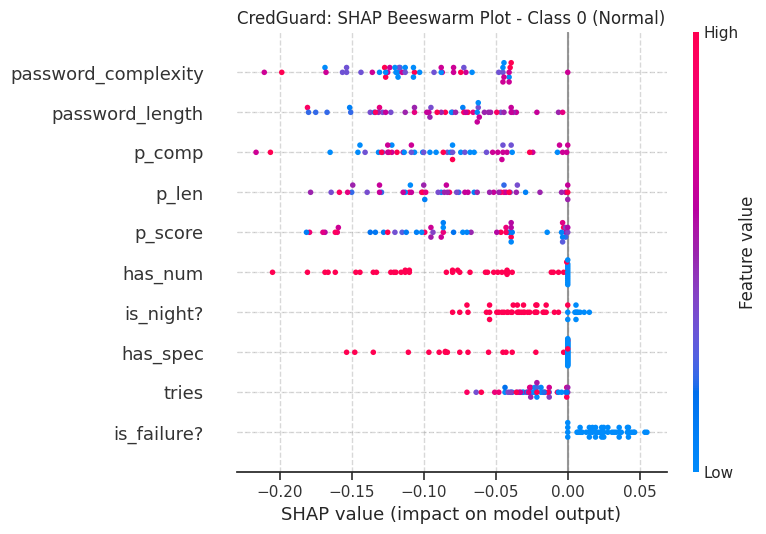


 Beeswarm Plot - Class 1 (Attack)


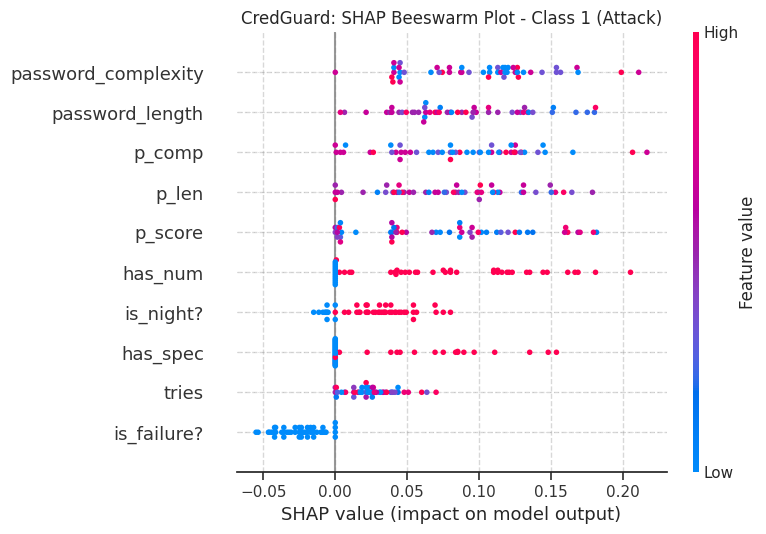

In [ ]:
# Beeswarm plots
shap_values_class_1 = shap_values.values
shap_values_class_0 = -shap_values.values

print("\nBeeswarm Plot")
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_class_0,
    X_sample_for_explainer,
    feature_names=X_test_scaled.columns.tolist(),
    max_display=10,
    plot_type="dot",
    show=False
)
plt.title("CredGuard: SHAP Beeswarm Plot - Class 0 (Normal)")
plt.grid(True, linestyle='--', alpha=0.3, color='gray')
plt.tight_layout()
plt.show()


print("\n Beeswarm Plot - Class 1 (Attack)")

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_class_1,
    X_sample_for_explainer,
    feature_names=X_test_scaled.columns.tolist(),
    max_display=10,
    plot_type="dot",
    show=False
)
plt.title("CredGuard: SHAP Beeswarm Plot - Class 1 (Attack)")
plt.grid(True, linestyle='--', alpha=0.3, color='gray')
plt.tight_layout()
plt.show()


Global Feature Importance


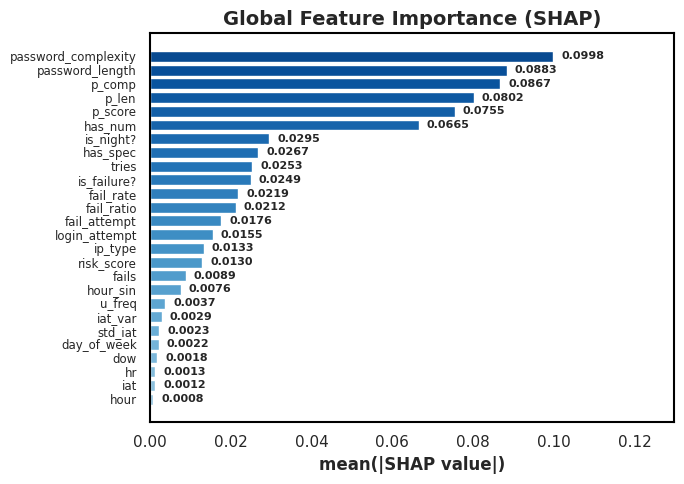

In [ ]:
print("\nGlobal Feature Importance")
shap_array_for_global = shap_values.values
mean_abs_shap = np.mean(np.abs(shap_array_for_global), axis=0)
importance_all = mean_abs_shap

all_indices = np.arange(len(importance_all))
mask = importance_all > 0.0001
filtered_indices = all_indices[mask]
importance = importance_all[mask]

feature_names = np.array(X_test_scaled.columns)[filtered_indices]

indices_sorted = np.argsort(importance)[::-1]
labels_for_plot = feature_names[indices_sorted].tolist()
importance_sorted = importance[indices_sorted]

plt.figure(figsize=(7, 5))

top_n = len(labels_for_plot)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, top_n))

bars = plt.barh(range(top_n), importance_sorted, color=colors[::-1])
plt.yticks(range(top_n), labels_for_plot, fontsize=8.5)
plt.xlabel('mean(|SHAP value|)', fontsize=12, fontweight='bold')
plt.title('Global Feature Importance (SHAP)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.xlim(0, importance_sorted.max() * 1.3)

# إطار
for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color('black')

# أرقام
for bar, val in zip(bars, importance_sorted):
    plt.text(bar.get_width() + (importance_sorted.max() * 0.02),
             bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

LIME Explanation

In [ ]:
normal_indices = y_test[y_test == 0].index[:3].tolist()
attack_indices = y_test[y_test == 1].index[:3].tolist()
samples_to_explain = normal_indices + attack_indices

LIME EXPLANATION (SVM):

Random sample selected: 29184
True label: Attack
Model predicted: Attack (confidence: 0.681)
LIME explaining class: Attack

Feature Contributions:
tries                               → -0.1331
fail_attempt                        → +0.1267
password_complexity                 → +0.1247
p_comp                              → +0.1195
p_len                               → +0.1157
password_length                     → +0.1092
has_num                             → +0.0902
p_score                             → +0.0793
login_attempt                       → -0.0740
ip_type                             → -0.0113


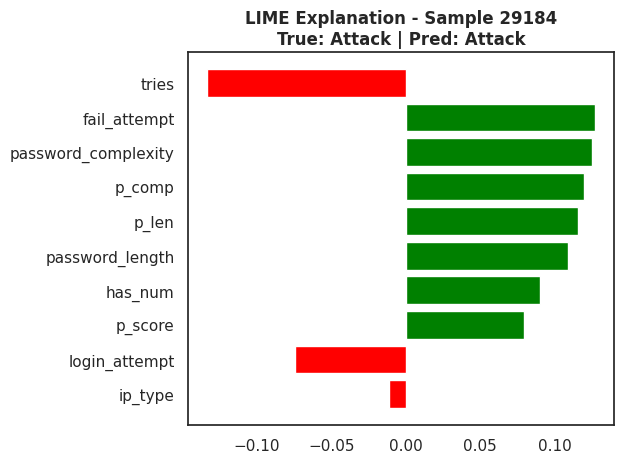

In [ ]:
print("LIME EXPLANATION (SVM):")
def predict_proba_lime(X_input_scaled_from_lime):
    X_input_scaled_from_lime = np.array(X_input_scaled_from_lime)

    if X_input_scaled_from_lime.ndim == 1:
        X_input_scaled_from_lime = X_input_scaled_from_lime.reshape(1, -1)

    return svm_model.predict_proba(X_input_scaled_from_lime)

X_lime_background = X_train_scaled.values
lime_feature_names = X_train_scaled.columns.tolist()

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_lime_background,
    feature_names=lime_feature_names,
    class_names=class_names,
    mode='classification',
    discretize_continuous=False,
    random_state=42
)

sample_idx = random.randint(0, len(X_test_scaled) - 1) # Use X_test_scaled length for index to ensure consistency

sample_values_for_lime = X_test_scaled.iloc[sample_idx].values # Get the scaled sample values for LIME

exp = explainer_lime.explain_instance(
    data_row=sample_values_for_lime, # Pass the scaled sample to LIME
    predict_fn=predict_proba_lime,
    num_features=10
)

single_sample_scaled = sample_values_for_lime.reshape(1, -1) # Already scaled, just reshape
pred_probs = svm_model.predict_proba(single_sample_scaled)
pred_class_idx = np.argmax(pred_probs, axis=1)[0]
pred_class_name = class_names[pred_class_idx]
confidence = pred_probs[0][pred_class_idx]

true_label = y_test.iloc[sample_idx]
true_label_name = class_names[true_label]

label_from_lime = exp.available_labels()[0]

print(f"\nRandom sample selected: {sample_idx}")
print(f"True label: {true_label_name}")
print(f"Model predicted: {pred_class_name} (confidence: {confidence:.3f})")
print(f"LIME explaining class: {class_names[label_from_lime]}")

if true_label != pred_class_idx:
    print(" MISCLASSIFICATION!")

print("\nFeature Contributions:")
for feature, weight in exp.as_list(label=label_from_lime):
   print(f"{feature:35} → {weight:+.4f}")

fig = exp.as_pyplot_figure(label=label_from_lime)

plt.title(
    f"LIME Explanation - Sample {sample_idx}\nTrue: {true_label_name} | Pred: {pred_class_name}",
    fontsize=12,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

SAVE MODEL


In [ ]:
print("SAVING MODEL")

model_files = {
    'model': svm_model,
    'scaler': scaler,
    'features': training_features
}

for name, obj in model_files.items():
    filename = f'svm_ids_{name}.pkl'
    joblib.dump(obj, filename)
    print(f"Saved: {filename}")

SAVING MODEL
Saved: svm_ids_model.pkl
Saved: svm_ids_scaler.pkl
Saved: svm_ids_features.pkl


 FINAL SUMMARY WITH ALL METRICS

In [ ]:
print("\n" + "="*70)
print("FINAL SUMMARY - ALL METRICS")
print("="*70)

start_time = time.time()
svm_model.predict(X_test_scaled)
end_time = time.time()
inference_speed = (end_time - start_time) / len(X_test_scaled)

print(f"""╔══════════════════════════════════════════════════════════╗
║                 MODEL PERFORMANCE SUMMARY                ║
╠══════════════════════════════════════════════════════════╣
║
║  ACCURACY:
║  • Training: {train_acc:.2%}
║  • Test: {test_acc:.2%}
║  • Validation: {val_acc:.2%}
║
║  SECURITY METRICS:
║  • Attack Detection Rate (Recall): {attack_recall:.2%}
║  • False Alarm Rate: {1 - normal_precision:.2%}
║  • System Reliability: {report['Attack']['precision']:.2%}
║
║  MODEL EFFICIENCY:
║  • Overall Accuracy: {test_acc:.2%}
║  • F1-Score (Weighted): {test_f1:.2%}
║  • Inference Speed: {inference_speed*1000:.4f} ms/sample
║
║  PER-CLASS F1-SCORES:
║  • Normal: {report['Normal']['f1-score']:.2%}
║  • Attack: {report['Attack']['f1-score']:.2%}
║
║  TOP FEATURES INFLUENCING DETECTION:
║  1. {top_features.iloc[0]['Feature']}
║  2. {top_features.iloc[1]['Feature']}
║  3. {top_features.iloc[2]['Feature']}
║
║  DATA DISTRIBUTION:
║  • Total samples: {len(df)}
║  • Features used: {len(training_features)}
║  • Train/Test/Val: {len(X_train)}/{len(X_test)}/{len(X_val)}
║
╚══════════════════════════════════════════════════════════╝
""")


FINAL SUMMARY - ALL METRICS
╔══════════════════════════════════════════════════════════╗
║                 MODEL PERFORMANCE SUMMARY                ║
╠══════════════════════════════════════════════════════════╣
║
║  ACCURACY:
║  • Training: 73.00%
║  • Test: 71.21%
║  • Validation: 77.15%
║
║  SECURITY METRICS:
║  • Attack Detection Rate (Recall): 64.62%
║  • False Alarm Rate: 31.81%
║  • System Reliability: 75.10%
║
║  MODEL EFFICIENCY:
║  • Overall Accuracy: 71.21%
║  • F1-Score (Weighted): 71.09%
║  • Inference Speed: 0.0003 ms/sample
║
║  PER-CLASS F1-SCORES:
║  • Normal: 72.76%
║  • Attack: 69.47%
║
║  TOP FEATURES INFLUENCING DETECTION:
║  1. tries
║  2. fail_attempt
║  3. p_comp
║
║  DATA DISTRIBUTION:
║  • Total samples: 1019867
║  • Features used: 21
║  • Train/Test/Val: 704222/142623/173022
║
╚══════════════════════════════════════════════════════════╝

